In [16]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

In [17]:
# parameters: 
# m = size of the dataset
# n2 = number of neurons in the second layer
# alpha = learning rate for the gradient descent
# Niter = number of iterations if the gradient descent

m = 120
n2 = 15
alpha = 0.3
Niter = 8000

In [18]:
# generation of the dataset
# for the reproductibility of the results, we initialize the random seed

np.random.seed(2023)

U=np.random.rand(1,m)

# X = input data
X=np.zeros((1,m))
X[0,0:int(m/2)] = np.sin(2*np.pi*U[0,0:int(m/2)])
X[0,int(m/2):] = np.exp(U[0,int(m/2):])-1


# y = output data 
# avant : y=np.ones((1,m)) y[0,int(m/2):] = 0.0

y=np.zeros((2,m))
y[0, 0:int(m/2)] = 1.0
y[1, int(m/2):] = 1.0

In [19]:
# activation function
def sigma(z):
    return 1/(1+np.exp(-z))

In [20]:
# derivative of the activation function
def sigma_prim(z):
    return np.exp(-z)/((1+np.exp(-z))**2)

In [ ]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [22]:
def compute_cost(a3, y, m):
    cost = (-1/m) * np.sum(y*np.log(a3))
    return cost

In [23]:
def predict(a3):
    return np.argmax(a3, axis=0)

In [24]:
# random initialization of the parameters of the neural network

W2 = np.random.randn(n2,1)
b2 = np.random.randn(n2,1)

#avant
#W3 = np.random.randn(1,n2)
#b3 = np.random.randn(1)

W3 = np.random.randn(2, n2)
b3 = np.random.randn(2,1)

In [25]:
# computation of the cost function with respect to W2, W3, b2, b3
# using the backpropagation algorithm

def compute_grad(x,y,W2,W3,b2,b3):
    A1 = x

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)

    #avant delta_3 = (A3-y)*sigma_prim(Z3) 
    delta_3 = A3 - y
    delta_2 = (np.transpose(W3)@delta_3)*sigma_prim(Z2)

    dC_W2 = (1/m)*delta_2@np.transpose(A1)
    dC_W3 = (1/m)*delta_3@np.transpose(A2)
    
    dC_b2 = (1/m)*np.sum(delta_2, axis=1).reshape((n2,1))
    dC_b3 = (1/m)*np.sum(delta_3, axis=1).reshape((2,1))
    
    return dC_W2, dC_W3, dC_b2, dC_b3

In [26]:
# Prediction of the model
def model_predict(X,W2,W3,b2,b3):
    
    A1 = X

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)
    
    return A3

In [27]:
# Main program

Cost = np.zeros(Niter)

for j in range(Niter):
    
    y_pred = model_predict(X,W2,W3,b2,b3)
    Cost[j] = compute_cost(y_pred, y, m)
        
    dC_dW2,dC_dW3,dC_db2,dC_db3 = compute_grad(X,y,W2,W3,b2,b3)

    W2 = W2 - alpha*dC_dW2
    W3 = W3 - alpha*dC_dW3
    b2 = b2 - alpha*dC_db2
    b3 = b3 - alpha*dC_db3

TypeError: exp() got an unexpected keyword argument 'axis'

In [ ]:
# Check the accuracy with the learning data
y_pred = model_predict(X,W2,W3,b2,b3)
#NOUVEAU
predictions = np.argmax(y_pred, axis=0)
labels = np.argmax(y, axis=0)
print("accuracy:", 100 * np.mean(predictions == labels), "%")


# Computation of the accuracy
# avant print('accuracy:',100*(1-np.sum(np.abs(np.round(y_pred)-y))/np.size(y)),'%')

accuracy: 72.5 %


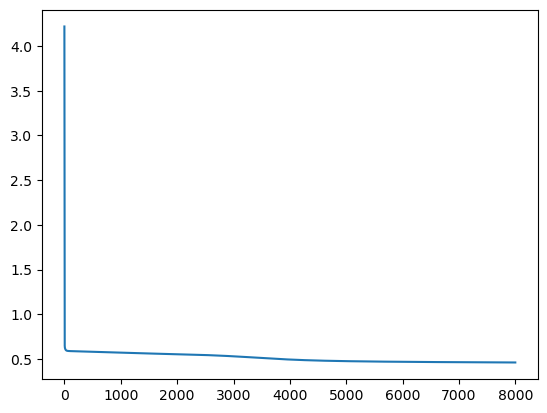

In [ ]:
# Courbe de la fonction cout en fonction des itérations
plt.plot(Cost)

In [ ]:
# test the model with data that it has never seen

# Generate new data
U_test=np.random.rand(1,120)
X_test=np.zeros((1,120))
X_test[0,0:60] = np.sin(2*np.pi*U_test[0,0:60])
X_test[0,60:] = np.exp(U_test[0,60:])-1

y_test=np.zeros((2,120))
y_test[0,0:60] = 1.0
y_test[1,60:] = 1.0

# model prediction
y_pred = model_predict(X_test,W2,W3,b2,b3)

predictions = np.argmax(y_pred, axis=0)
labels = np.argmax(y_test, axis=0)
print("accuracy:", 100 * np.mean(predictions == labels), "%")

accuracy: 75.83333333333333 %
